# Import Libaries

In [85]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 0. Load data

In [48]:
path = kagglehub.dataset_download(
    "aslanahmedov/walmart-sales-forecast",
    output_dir="data"
)

DATA_DIR = Path(path)

FEATURES_DIR = DATA_DIR / "features.csv"
STORES_DIR = DATA_DIR / "stores.csv"
TEST_DIR = DATA_DIR / "test.csv"
TRAIN_DIR = DATA_DIR / "train.csv"

print("Path to features dataset files:", FEATURES_DIR)
print("Path to stores dataset files:", STORES_DIR)
print("Path to test dataset files:", TEST_DIR)
print("Path to train dataset files:", TRAIN_DIR)

Path to features dataset files: data\features.csv
Path to stores dataset files: data\stores.csv
Path to test dataset files: data\test.csv
Path to train dataset files: data\train.csv


# 1. Data inspection

In [49]:
features_df = pd.read_csv(FEATURES_DIR)
stores_df = pd.read_csv(STORES_DIR)
test_df = pd.read_csv(TEST_DIR)
train_df = pd.read_csv(TRAIN_DIR)

data_frames = {
    "features": features_df,
    "stores": stores_df,
    "test": test_df,
    "train": train_df
}

for name, df in data_frames.items():
    print("Data:", name.capitalize())
    print("Shape:", df.shape)
    print("Columns", list(df.columns))
    display(df.head(1))
    print()

Data: Features
Shape: (8190, 12)
Columns ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False



Data: Stores
Shape: (45, 3)
Columns ['Store', 'Type', 'Size']


,Store,Type,Size
0,1,A,151315



Data: Test
Shape: (115064, 4)
Columns ['Store', 'Dept', 'Date', 'IsHoliday']


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False



Data: Train
Shape: (421570, 5)
Columns ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.5,False


### Info
The dataset consists of four smaller datasets: `Features`, `Stores`, `Train`, and `Test`.
The `Features` dataset contains weekly information about each store, including **Temperature**, **Fuel Price**, **CPI**, **Unemployment**, **MarkDowns**, and holiday information.
The `Stores` dataset identifies each store and provides additional information such as its **Type** and **Size**.
The `Train` and `Test` datasets contain the main forecasting data, including **Store**, **Department**, **Date**, and **IsHoliday**. The `Train` dataset also contains the target variable, **Weekly_Sales**, which we will use to train the forecasting model.

# 2. Explorary data analysis

In [50]:
for name, df in data_frames.items():
    print(f"\n{name.upper()}")
    print(df.dtypes)


FEATURES
Store             int64
Date                str
Temperature     float64
Fuel_Price      float64
MarkDown1       float64
MarkDown2       float64
MarkDown3       float64
MarkDown4       float64
MarkDown5       float64
CPI             float64
Unemployment    float64
IsHoliday          bool
dtype: object

STORES
Store    int64
Type       str
Size     int64
dtype: object

TEST
Store        int64
Dept         int64
Date           str
IsHoliday     bool
dtype: object

TRAIN
Store             int64
Dept              int64
Date                str
Weekly_Sales    float64
IsHoliday          bool
dtype: object


### Info
Almost all features are stored as `int64` or `float64` data types. The exceptions are `Date` and `Type`, which are stored as strings (`str`), and `IsHoliday`, which contains boolean (`bool`) values.

In [51]:
for name, df in data_frames.items():
    print((df.isna().mean() * 100).sort_values(ascending=False))
    print()

MarkDown2       64.334554
MarkDown4       57.704518
MarkDown3       55.885226
MarkDown1       50.769231
MarkDown5       50.549451
CPI              7.142857
Unemployment     7.142857
Store            0.000000
Fuel_Price       0.000000
Temperature      0.000000
Date             0.000000
IsHoliday        0.000000
dtype: float64

Store    0.0
Type     0.0
Size     0.0
dtype: float64

Store        0.0
Dept         0.0
Date         0.0
IsHoliday    0.0
dtype: float64

Store           0.0
Dept            0.0
Date            0.0
Weekly_Sales    0.0
IsHoliday       0.0
dtype: float64



### Info
There are a significant number of missing values in the `MarkDown` features, ranging from approximately **50% to 64%**. This will require further investigation before deciding how to handle these missing values.

In [52]:
for name, df in data_frames.items():
    if "Date" in df.columns:
        print(
            name,
            df["Date"].min(),
            df["Date"].max()
        )

features 2010-02-05 2013-07-26
test 2012-11-02 2013-07-26
train 2010-02-05 2012-10-26


### Info
The dates are correctly ordered and cover the period from the beginning of **2010 to the second half of 2012**.

In [53]:
train_df["Weekly_Sales"].describe()

count    421570.000000
mean      15981.258123
std       22711.183519
min       -4988.940000
25%        2079.650000
50%        7612.030000
75%       20205.852500
max      693099.360000
Name: Weekly_Sales, dtype: float64

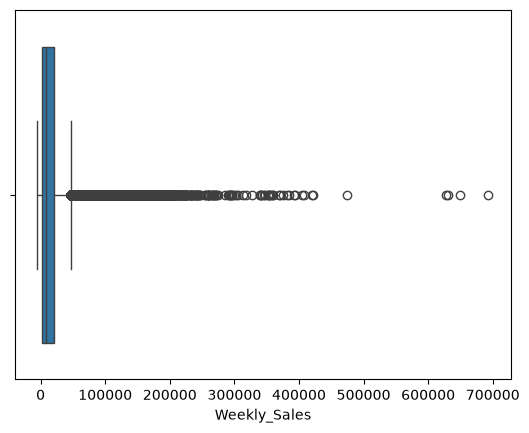

In [54]:
sns.boxplot(data=train_df, x="Weekly_Sales")
plt.show()

### Observation
The `Weekly_Sales` variable has a relatively high standard deviation compared to its mean, indicating substantial variation in sales across stores and departments. The values range from approximately **-5K to nearly 700K**, suggesting the presence of both negative sales and extreme high values.

The negative values may represent returns or sales adjustments, while the large positive values may be caused by differences between stores and departments.

In [55]:
train_df.groupby("Store")["Weekly_Sales"].mean().describe()

count       45.000000
mean     15438.091939
std       7011.232951
min       5053.415813
25%       9002.493073
50%      13803.596986
75%      19776.180881
max      29508.301592
Name: Weekly_Sales, dtype: float64

### Observation
The distribution of mean sales values and the boxplot above show that the extremely high sales values are outliers. These spikes appear to occur on specific dates, likely corresponding to periods with increased customer demand, such as major holidays or other peak shopping periods.

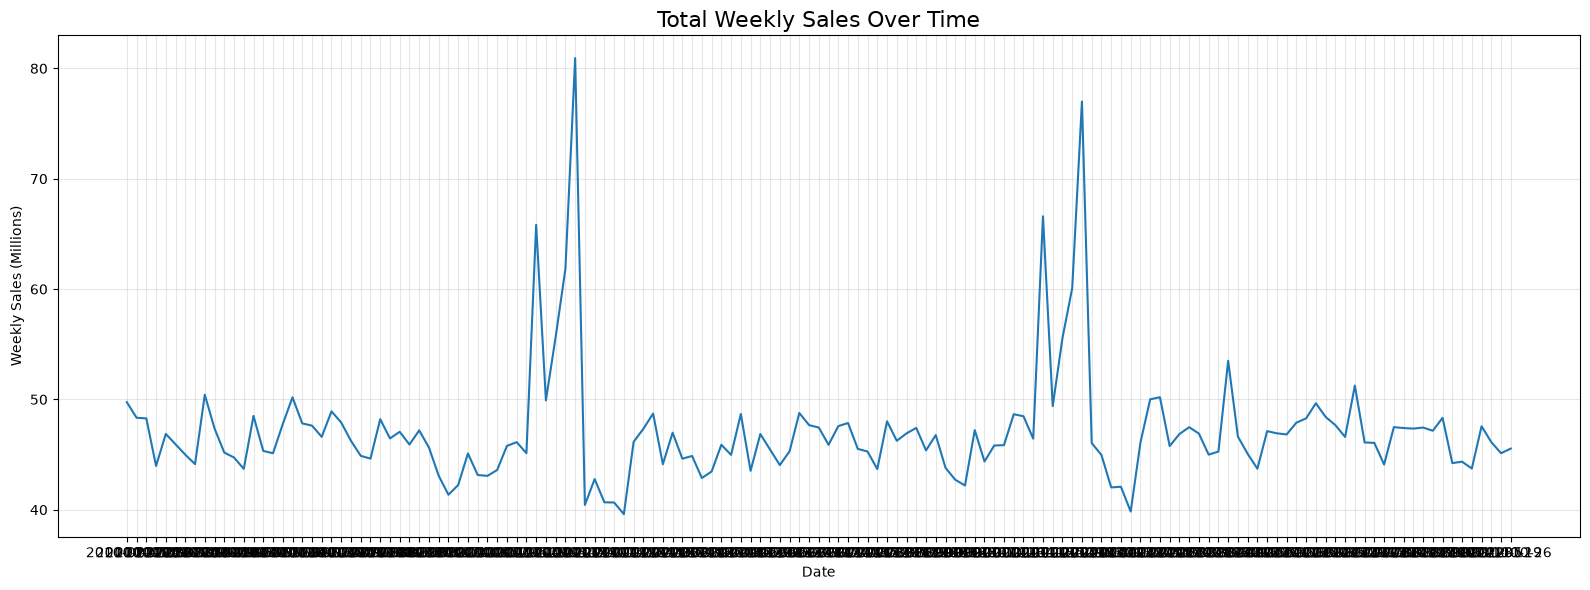

In [56]:
weekly_sales = (
    train_df
    .groupby("Date")["Weekly_Sales"]
    .sum()
    .reset_index()
)

weekly_sales["Sales_Millions"] = weekly_sales["Weekly_Sales"] / 1_000_000

plt.figure(figsize=(16, 6))

sns.lineplot(
    data=weekly_sales,
    x="Date",
    y="Sales_Millions",
    linewidth=1.5
)

plt.title("Total Weekly Sales Over Time", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Weekly Sales (Millions)")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

### Observation
The plot above clearly shows the trend in weekly sales over time. A significant spike in sales can be observed around the Christmas period, while during the rest of the year, weekly sales generally fluctuate within a range of approximately **±5 million** around the usual level.

# 3. Data preparation

## 3.1 Merge Data
The required information is currently distributed across multiple datasets. We will merge them into a single DataFrame containing all relevant features needed for the forecasting model.

In [57]:
train_merged = train_df.merge(
    features_df,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

train_merged = train_merged.merge(
    stores_df,
    on="Store",
    how="left"
)

print("Original train:", train_df.shape)
print("Merged train:", train_merged.shape)
train_merged.head()

Original train: (421570, 5)
Merged train: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


## 3.2 Convert Date to Proper Format
We can now extract additional time-related features such as `Year`, `Month`, and `Week`.

In [58]:
train_merged["Date"] = pd.to_datetime(train_merged["Date"])

train_merged["Year"] = train_merged["Date"].dt.year
train_merged["Month"] = train_merged["Date"].dt.month
train_merged["Week"] = train_merged["Date"].dt.isocalendar().week

In [59]:
cols = [
    "Store",
    "Dept",
    "Type",
    "Size",
    
    "Date",
    "Year",
    "Month",
    "Week",
    
    "IsHoliday",
    
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",

    "Weekly_Sales"
]

train_merged = train_merged[cols]
train_merged.head(3)

,Store,Dept,Type,Size,Date,Year,Month,Week,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Weekly_Sales
0,1,1,A,151315,2010-02-05,2010,2,5,False,42.31,2.572,211.096358,8.106,NaN,NaN,NaN,NaN,NaN,24924.50
1,1,1,A,151315,2010-02-12,2010,2,6,True,38.51,2.548,211.242170,8.106,NaN,NaN,NaN,NaN,NaN,46039.49
2,1,1,A,151315,2010-02-19,2010,2,7,False,39.93,2.514,211.289143,8.106,NaN,NaN,NaN,NaN,NaN,41595.55


## 3.3 Handle Missing Values

In [60]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

train_merged[markdown_cols] = train_merged[markdown_cols].fillna(0)

train_merged[markdown_cols].isna().sum()

MarkDown1    0
MarkDown2    0
MarkDown3    0
MarkDown4    0
MarkDown5    0
dtype: int64

### Observation
The missing values are concentrated in the `MarkDown` features. Since these columns represent promotional markdowns, missing values can be interpreted as periods when no markdown was active. Therefore, the missing values were replaced with `0`.

## 3.4 One-Hot-Encoding String Types

In [61]:
train_merged["Type"].value_counts()

train_merged = pd.get_dummies(
    train_merged,
    columns=["Type"],
    dtype=int
)

train_merged["IsHoliday"] = train_merged["IsHoliday"].astype(int)

train_merged.head(3)

,Store,Dept,Size,Date,Year,Month,Week,IsHoliday,Temperature,Fuel_Price,...,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Weekly_Sales,Type_A,Type_B,Type_C
0,1,1,151315,2010-02-05,2010,2,5,0,42.31,2.572,...,8.106,0.0,0.0,0.0,0.0,0.0,24924.50,1,0,0
1,1,1,151315,2010-02-12,2010,2,6,1,38.51,2.548,...,8.106,0.0,0.0,0.0,0.0,0.0,46039.49,1,0,0
2,1,1,151315,2010-02-19,2010,2,7,0,39.93,2.514,...,8.106,0.0,0.0,0.0,0.0,0.0,41595.55,1,0,0


## Info
The `Type` column contains categorical values without any natural order. Therefore, One-Hot Encoding was used to convert the store types into numerical features that can be processed by the model. The `IsHoliday` column was also converted from boolean values to binary values, where `False` is represented as `0` and `True` as `1`.

## 3.5 Train/Validation/Test Split

In [62]:
train_merged = train_merged.sort_values(
    ["Store", "Dept", "Date"]
).reset_index(drop=True)

train_merged.head(3)

,Store,Dept,Size,Date,Year,Month,Week,IsHoliday,Temperature,Fuel_Price,...,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Weekly_Sales,Type_A,Type_B,Type_C
0,1,1,151315,2010-02-05,2010,2,5,0,42.31,2.572,...,8.106,0.0,0.0,0.0,0.0,0.0,24924.50,1,0,0
1,1,1,151315,2010-02-12,2010,2,6,1,38.51,2.548,...,8.106,0.0,0.0,0.0,0.0,0.0,46039.49,1,0,0
2,1,1,151315,2010-02-19,2010,2,7,0,39.93,2.514,...,8.106,0.0,0.0,0.0,0.0,0.0,41595.55,1,0,0


In [63]:
train_merged["Date"].min(), train_merged["Date"].max()

(Timestamp('2010-02-05 00:00:00'), Timestamp('2012-10-26 00:00:00'))

In [64]:
train_data = train_merged[
    train_merged["Date"] < "2012-01-01"
].copy()

val_data = train_merged[
    (train_merged["Date"] >= "2012-01-01") &
    (train_merged["Date"] <= "2012-07-01")
].copy()

test_data = train_merged[
    train_merged["Date"] >= "2012-07-01"
].copy()

print("Train:", train_data.shape)
print("Validation:", val_data.shape)
print("Test:", test_data.shape)

print("\nDate ranges:")
print("Train:", train_data["Date"].min(), "-", train_data["Date"].max())
print("Validation:", val_data["Date"].min(), "-", val_data["Date"].max())
print("Test:", test_data["Date"].min(), "-", test_data["Date"].max())

Train: (294132, 21)
Validation: (77110, 21)
Test: (50328, 21)

Date ranges:
Train: 2010-02-05 00:00:00 - 2011-12-30 00:00:00
Validation: 2012-01-06 00:00:00 - 2012-06-29 00:00:00
Test: 2012-07-06 00:00:00 - 2012-10-26 00:00:00


## 3.6 Feature Scaling

In [65]:
scaled_features = [
    "Size",
    "Year",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

target_col = "Weekly_Sales"


feature_scaler = StandardScaler()
target_scaler = StandardScaler()

feature_scaler.fit(train_data[scaled_features])
target_scaler.fit(train_data[["Weekly_Sales"]])

# Feature
train_data[scaled_features] = feature_scaler.transform(
    train_data[scaled_features]
)

val_data[scaled_features] = feature_scaler.transform(
    val_data[scaled_features]
)

test_data[scaled_features] = feature_scaler.transform(
    test_data[scaled_features]
)

# Target
train_data["Weekly_Sales"] = target_scaler.transform(
    train_data[["Weekly_Sales"]]
).ravel()

val_data["Weekly_Sales"] = target_scaler.transform(
    val_data[["Weekly_Sales"]]
).ravel()

test_data["Weekly_Sales"] = target_scaler.transform(
    test_data[["Weekly_Sales"]]
).ravel()

train_data.head(1)

,Store,Dept,Size,Date,Year,Month,Week,IsHoliday,Temperature,Fuel_Price,...,Unemployment,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,Weekly_Sales,Type_A,Type_B,Type_C
0,1,1,0.236801,2010-02-05,-1.044415,2,5,0,-0.87668,-1.452341,...,-0.067814,-0.188888,-0.103036,-0.098191,-0.157526,-0.193251,0.38409,1,0,0


In [66]:
for df in [train_data, val_data, test_data]:
    df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

    df["Week_sin"] = np.sin(2 * np.pi * df["Week"] / 52)
    df["Week_cos"] = np.cos(2 * np.pi * df["Week"] / 52)

for df in [train_data, val_data, test_data]:
    df.drop(columns=["Month", "Week"], inplace=True)

### Info
The `Month` and `Week` features were transformed using cyclic encoding. This approach represents each time period using sine and cosine values, allowing the model to recognize the cyclic nature of time. For example, December and January are treated as neighboring periods rather than distant numerical values.

In [67]:
train_data["Store"] = train_data["Store"].astype(int)
val_data["Store"] = val_data["Store"].astype(int)
test_data["Store"] = test_data["Store"].astype(int)

train_data["Dept"] = train_data["Dept"].astype(int)
val_data["Dept"] = val_data["Dept"].astype(int)
test_data["Dept"] = test_data["Dept"].astype(int)

### Info
The `Store` and `Dept` columns represent categorical identifiers rather than continuous numerical features. They were kept as integer IDs and will later be converted into learnable embeddings using PyTorch's `nn.Embedding` layers.

# 4. Sequence Generation

## 4.1 Sort data and preapare sequence features

In [68]:
SEQ_LEN = 12

# Sort data
for df in [train_data, val_data, test_data]:
    df.sort_values(
        ["Store", "Dept", "Date"],
        inplace=True
    )

# Sequence features
sequence_features = [
    "Size",
    "Year",
    "IsHoliday",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",
    "Type_A",
    "Type_B",
    "Type_C",
    "Month_sin",
    "Month_cos",
    "Week_sin",
    "Week_cos"
]

## 4.2 Create train sequences

In [69]:
def create_all_sequences(df, features, target, seq_len=SEQ_LEN):
    X = []
    y = []
    stores = []
    depts = []

    for (store, dept), group in df.groupby(["Store", "Dept"]):

        group = group.sort_values("Date")

        values = group[features].values
        targets = group[target].values

        for i in range(len(group) - seq_len):
            X.append(values[i:i+seq_len])
            y.append(targets[i+seq_len])

            stores.append(store)
            depts.append(dept)

    return (
        np.array(X),
        np.array(stores),
        np.array(depts),
        np.array(y)
    )

X_train, store_train, dept_train, y_train = create_all_sequences(
    train_data,
    sequence_features,
    "Weekly_Sales",
    SEQ_LEN
)

print("X_train:", X_train.shape)
print("store_train:", store_train.shape)
print("dept_train:", dept_train.shape)
print("y_train:", y_train.shape)

print("X_train:", X_train)
print("store_train:", store_train)
print("dept_train:", dept_train)
print("y_train:", y_train)

X_train: (256034, 12, 19)
store_train: (256034,)
dept_train: (256034,)
y_train: (256034,)
X_train: [[[0.23680124592288784 -1.0444148913084457 0 ... 0.5000000000000001
   0.5680647467311558 0.8229838658936564]
  [0.23680124592288784 -1.0444148913084457 1 ... 0.5000000000000001
   0.6631226582407952 0.7485107481711011]
  [0.23680124592288784 -1.0444148913084457 0 ... 0.5000000000000001
   0.7485107481711011 0.6631226582407953]
  ...
  [0.23680124592288784 -1.0444148913084457 0 ... -0.4999999999999998
   0.992708874098054 -0.12053668025532288]
  [0.23680124592288784 -1.0444148913084457 0 ... -0.4999999999999998
   0.9709418174260521 -0.2393156642875575]
  [0.23680124592288784 -1.0444148913084457 0 ... -0.4999999999999998
   0.9350162426854148 -0.35460488704253545]]

 [[0.23680124592288784 -1.0444148913084457 1 ... 0.5000000000000001
   0.6631226582407952 0.7485107481711011]
  [0.23680124592288784 -1.0444148913084457 0 ... 0.5000000000000001
   0.7485107481711011 0.6631226582407953]
  [0.2

## 4.3 Create validation and test sequences

In [70]:
def create_sequences_with_context(
    previous_df, 
    current_df, 
    features,
    target,
    seq_len=12
):
    X = []
    y = []
    stores = []
    depts = []

    for (store, dept), current_group in current_df.groupby(["Store", "Dept"]):
        previous_group = previous_df[
            (previous_df["Store"] == store) &
            (previous_df["Dept"] == dept)
        ]

        previous_group = previous_group.sort_values("Date")
        current_group = current_group.sort_values("Date")

        # Last 12 observations from previous split
        context = previous_group.tail(seq_len)

        # Combine context with current split
        group = pd.concat(
            [context, current_group]
        ).sort_values("Date")

        values = group[features].values
        targets = group[target].values

        context_len = len(context)

        for i in range(context_len, len(group)):
            if i < seq_len:
                continue

            X.append(values[i-seq_len:i])
            y.append(targets[i])

            stores.append(store)
            depts.append(dept)

    return (
        np.array(X),
        np.array(stores),
        np.array(depts),
        np.array(y)
    )

X_val, store_val, dept_val, y_val = create_sequences_with_context(
    train_data,
    val_data,
    sequence_features,
    "Weekly_Sales",
    SEQ_LEN
)

X_test, store_test, dept_test, y_test = create_sequences_with_context(
    val_data,
    test_data,
    sequence_features,
    "Weekly_Sales",
    SEQ_LEN
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (256034, 12, 19)
X_val: (76725, 12, 19)
X_test: (49945, 12, 19)
y_train: (256034,)
y_val: (76725,)
y_test: (49945,)


# 5. Create Datasets

In [71]:
class WalmartSalesDataset(Dataset):
    def __init__(self, X, y, stores, depts):
        X = np.asarray(X, dtype=np.float32)
        y = np.asarray(y, dtype=np.float32)
        stores = np.asarray(stores, dtype=np.int64)
        depts = np.asarray(depts, dtype=np.int64)

        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y)
        self.stores = torch.from_numpy(stores - 1)
        self.depts = torch.from_numpy(depts - 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return {
            "X": self.X[idx],
            "y": self.y[idx],
            "store": self.stores[idx],
            "dept": self.depts[idx]
        }

train_dataset = WalmartSalesDataset(X_train, y_train, store_train, dept_train)
val_dataset   = WalmartSalesDataset(X_val, y_val, store_val, dept_val)
test_dataset  = WalmartSalesDataset(X_test, y_test, store_test, dept_test)

print(f"Number of samples in training set: {len(train_dataset)}")
print(f"Number of samples in validation set: {len(val_dataset)}")
print(f"Number of samples in test set:     {len(test_dataset)}")

Number of samples in training set: 256034
Number of samples in validation set: 76725
Number of samples in test set:     49945


# 6. Create Dataloader

In [72]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Number of batches in training set: {len(train_loader)}")
print(f"Number of batches in validation set: {len(val_loader)}")
print(f"Number of batches in test set: {len(test_loader)}")

Number of batches in training set: 4001
Number of batches in validation set: 1199
Number of batches in test set: 781


# 7. Create model

In [73]:
class LSTMModel(nn.Module):
    def __init__(
        self, 
        input_size,
        hidden_size,
        store_count, 
        dept_count, 
        embedding_dim=8
    ):
        super().__init__()

        self.store_embedding = nn.Embedding(
            store_count, 
            embedding_dim
        )

        self.dept_embedding = nn.Embedding(
            dept_count,
            embedding_dim
        )

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden_size + 2 * embedding_dim,
            1
        )

    def forward(self, x, store, dept):

        lstm_out, _ = self.lstm(x)
        lstm_out = lstm_out[:, -1, :]

        store_embedded = self.store_embedding(store)
        dept_embedded = self.dept_embedding(dept)

        combined = torch.cat(
            [lstm_out, store_embedded, dept_embedded],
            dim=1
        )

        output = self.fc(combined)

        return output.squeeze(1)

model = LSTMModel(
    input_size=len(sequence_features),
    hidden_size=64,
    store_count=train_data["Store"].max(),
    dept_count=train_data["Dept"].max(),
    embedding_dim=8
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

LSTMModel(
  (store_embedding): Embedding(45, 8)
  (dept_embedding): Embedding(99, 8)
  (lstm): LSTM(19, 64, batch_first=True)
  (fc): Linear(in_features=80, out_features=1, bias=True)
)

# 8. Create training loop

In [74]:
EPOCHS = 50
PATIENCE = 5

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

train_losses = []
val_losses = []
best_val_loss = float("inf")
patience_counter = 0


def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0.0

    for batch in loader:

        X = batch["X"].to(device)
        y = batch["y"].to(device)
        stores = batch["store"].to(device)
        depts = batch["dept"].to(device)

        optimizer.zero_grad()

        predictions = model(X, stores, depts)

        loss = criterion(predictions, y)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * X.size(0)

    average_loss = total_loss / len(loader.dataset)

    return average_loss


def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:

            X = batch["X"].to(device)
            y = batch["y"].to(device)
            stores = batch["store"].to(device)
            depts = batch["dept"].to(device)

            predictions = model(X, stores, depts)

            loss = criterion(predictions, y)

            total_loss += loss.item() * X.size(0)

    average_loss = total_loss / len(loader.dataset)

    return average_loss

# 9. Train the model

In [75]:
for epoch in range(EPOCHS):

    train_loss = train_one_epoch(
        model, 
        train_loader, 
        criterion, 
        optimizer, 
        device
    )

    val_loss = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")

    else:
        patience_counter += 1

        if patience_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

Epoch [1/50] Train Loss: 0.4397 Val Loss: 0.3218
Epoch [2/50] Train Loss: 0.3645 Val Loss: 0.3058
Epoch [3/50] Train Loss: 0.3626 Val Loss: 0.2974
Epoch [4/50] Train Loss: 0.3623 Val Loss: 0.2970
Epoch [5/50] Train Loss: 0.3619 Val Loss: 0.3021
Epoch [6/50] Train Loss: 0.3616 Val Loss: 0.2946
Epoch [7/50] Train Loss: 0.3612 Val Loss: 0.3009
Epoch [8/50] Train Loss: 0.3612 Val Loss: 0.3039
Epoch [9/50] Train Loss: 0.3609 Val Loss: 0.2993
Epoch [10/50] Train Loss: 0.3608 Val Loss: 0.3040
Epoch [11/50] Train Loss: 0.3607 Val Loss: 0.3011
Early stopping triggered.


# 10. Plot the model losses

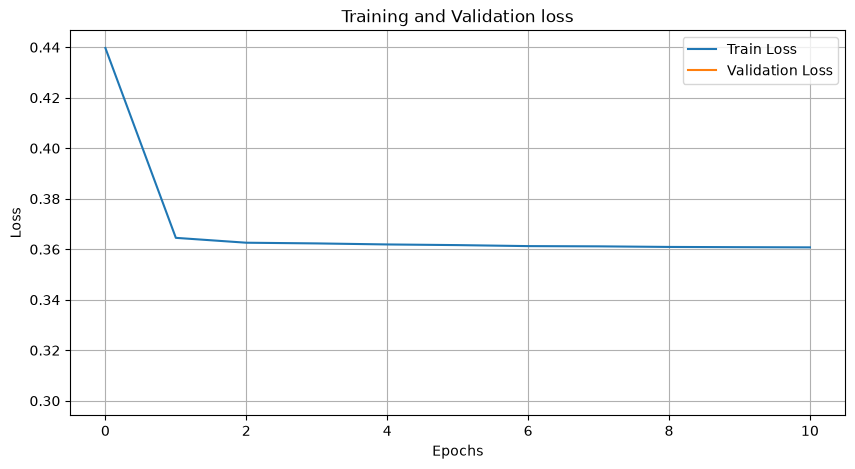

In [77]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation loss")

plt.legend()
plt.grid()
plt.show()

### Observation
As the plot shows, the model's loss changes very little after the first epoch. We can observe only a slight improvement of around 0.005, indicating that the model quickly reaches a stable level of performance.

# 11. Test the model on the test set

In [83]:
model.load_state_dict(
    torch.load("best_model.pth")
)

model.eval()


actuals = []
predictions = []

with torch.no_grad():

    for batch in test_loader:

        X = batch["X"].to(device)
        y = batch["y"].to(device)

        stores = batch["store"].to(device)
        depts = batch["dept"].to(device)

        output = model(X, stores, depts)

        predictions.extend(output.cpu().numpy())
        actuals.extend(y.cpu().numpy())


predictions = np.array(predictions)
actuals = np.array(actuals)


predictions_original = target_scaler.inverse_transform(
    predictions.reshape(-1, 1)
).ravel()

actuals_original = target_scaler.inverse_transform(
    actuals.reshape(-1, 1)
).ravel()

In [ ]:
mae = mean_absolute_error(
    actuals_original,
    predictions_original
)

rmse = np.sqrt(
    mean_squared_error(
        actuals_original,
        predictions_original
    )
)

r2 = r2_score(
    actuals_original,
    predictions_original
)

print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²:   {r2:.4f}")

MAE:  $7,859.42
RMSE: $12,220.87
R²:   0.6917


### Info
The model is able to explain almost **70%** of the variation in sales, with an average prediction error of around **$8K**. The results are reasonable for a baseline model, but there is still room for improvement. Adding more LSTM layers, dropout, and longer sequences could help the model capture more complex patterns and improve its predictions.

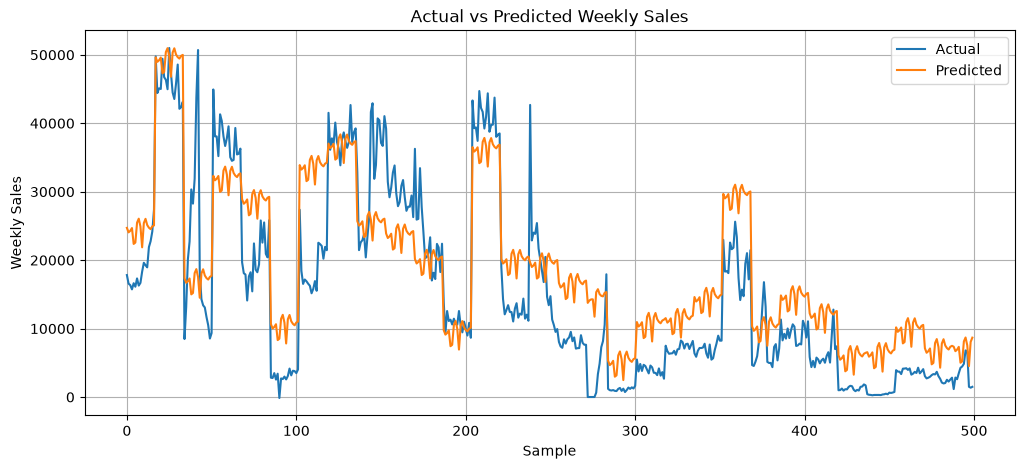

In [87]:
plt.figure(figsize=(12, 5))

plt.plot(
    actuals_original[:500],
    label="Actual"
)

plt.plot(
    predictions_original[:500],
    label="Predicted"
)

plt.xlabel("Sample")
plt.ylabel("Weekly Sales")
plt.title("Actual vs Predicted Weekly Sales")

plt.legend()
plt.grid()

plt.show()

### Observation
As the plot above shows, the model was able to follow the overall trend, but its predictions were often significantly above or below the actual sales values.